In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
data = {
    "YearsExperience": [
        1.1, 1.3, 1.5, 2.0, 2.2,
        2.9, 3.0, 3.2, 3.7, 3.9,
        4.0, 4.5, 4.9, 5.1, 5.3,
        5.9, 6.0, 6.8, 7.1, 7.9,
        8.2, 8.7, 9.0, 9.5, 10.3
    ],
    "Salary": [
        39343, 46205, 37731, 43525, 39891,
        56642, 60150, 54445, 57189, 63218,
        55794, 56957, 57081, 66029, 83088,
        81363, 93940, 91738, 98273, 101302,
        113812, 109431, 105582, 116969, 122391
    ]
}

df = pd.DataFrame(data)

df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [3]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(25, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  25 non-null     float64
 1   Salary           25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes
None
       YearsExperience         Salary
count        25.000000      25.000000
mean          5.120000   74083.560000
std           2.736177   27261.541719
min           1.100000   37731.000000
25%           3.000000   55794.000000
50%           4.900000   63218.000000
75%           7.100000   98273.000000
max          10.300000  122391.000000
YearsExperience    0
Salary             0
dtype: int64


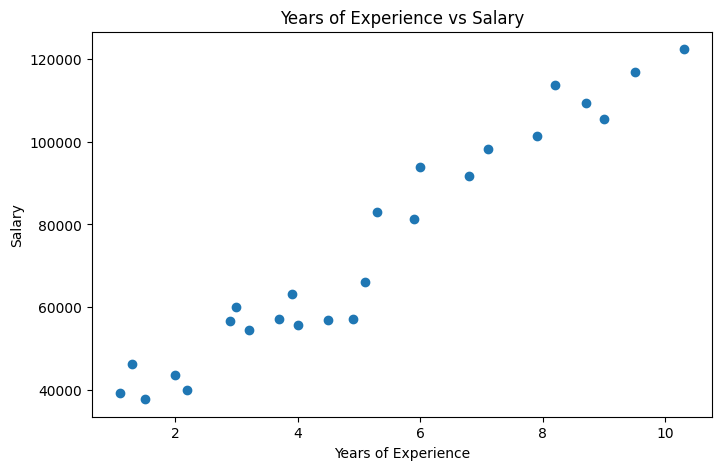

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["YearsExperience"],
    df["Salary"]
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.show()

In [5]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25, 1)
y shape: (25,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 20
Testing samples: 5


In [9]:
model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

LinearRegression()

In [11]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 24713.647341420554
Coefficient: 9626.143926081288


In [12]:
print(
    f"Salary = {model.intercept_:.2f} + "
    f"{model.coef_[0]:.2f} × YearsExperience"
)

Salary = 24713.65 + 9626.14 × YearsExperience


In [13]:
y_pred = model.predict(X_test)

In [14]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison

,Actual Salary,Predicted Salary
0,57189,60330.379868
1,93940,82470.510898
2,39343,35302.405660
3,116969,116162.014639
4,56957,68031.295009


In [15]:
years = [[7]]

predicted_salary = model.predict(years)

print(
    f"Predicted salary for 7 years of experience: "
    f"{predicted_salary[0]:.2f}"
)

Predicted salary for 7 years of experience: 92096.65


C:\Users\khand\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


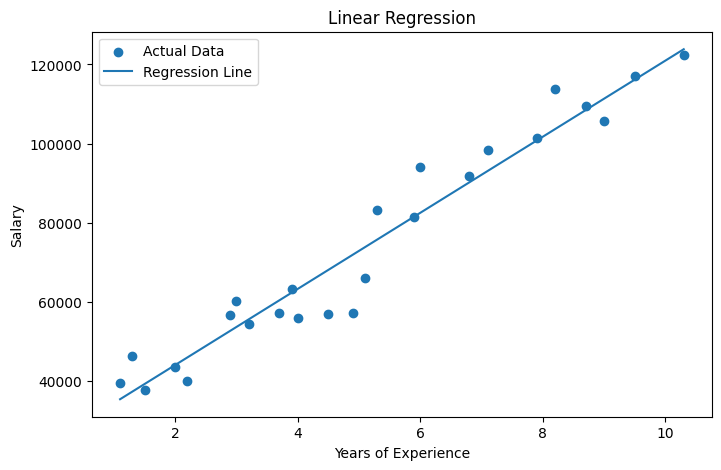

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")

plt.legend()
plt.show()

In [17]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 6106.548735899327


In [18]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 56207017.134264186


In [19]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 7497.133927993029


In [20]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9299486383908958


In [21]:
print("R² Score:", model.score(X_test, y_test))

R² Score: 0.9299486383908958


In [22]:
residuals = y_test - y_pred

residuals

8     -3141.379868
16    11469.489102
0      4040.594340
23      806.985361
11   -11074.295009
Name: Salary, dtype: float64

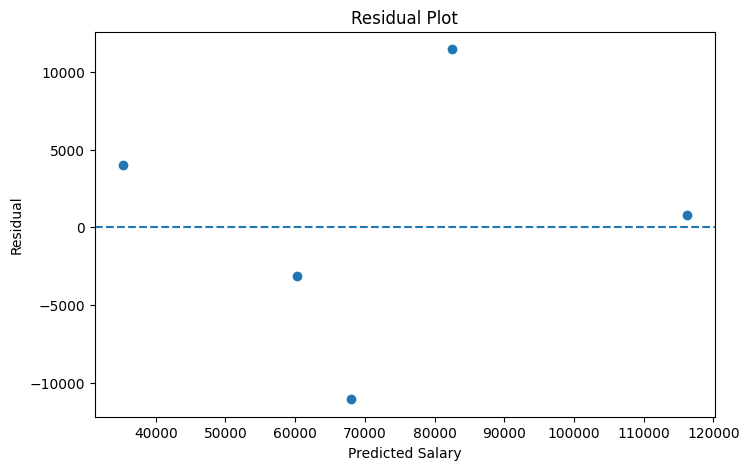

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Salary")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

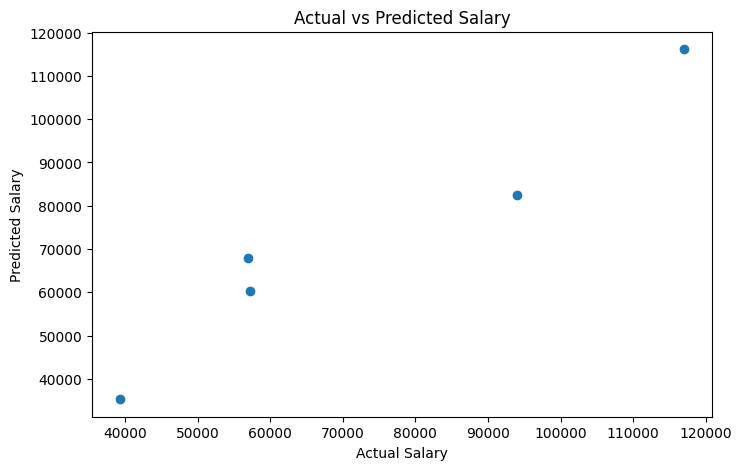

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [25]:
print("Linear Regression Model")
print("-" * 35)

print(f"Intercept : {model.intercept_:.2f}")
print(f"Coefficient : {model.coef_[0]:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Linear Regression Model
-----------------------------------
Intercept : 24713.65
Coefficient : 9626.14
MAE : 6106.55
MSE : 56207017.13
RMSE : 7497.13
R² Score : 0.9299
